In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.impute as kNNImputer
from sklearn.preprocessing import MinMaxScaler

oilData = pd.read_csv("oil_presence_trainset.csv")

In [2]:
oilData.head(10)

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Limestone,17.667992,834.277472,NaN,0.705933,2.431355,2228.0,1
1,Limestone,27.665758,578.158034,NaN,0.545806,2.606158,1610.0,0
2,Sandstone,28.855946,404.790685,NaN,0.167530,1.143136,2344.0,0
3,Sandstone,0.410957,887.836673,Dome,0.026852,2.673532,NaN,0
4,Shale,16.490538,562.288802,NaN,NaN,2.064440,NaN,0
5,Shale,16.654792,979.154784,Anticline,0.044457,4.927771,3556.0,1
6,Limestone,8.342985,NaN,Fault,NaN,0.439339,NaN,0
7,Shale,13.111546,263.806644,Fault,0.375041,4.602919,NaN,0
8,Shale,NaN,NaN,Fault,NaN,0.672804,867.0,0
9,Sandstone,28.419000,728.106328,Anticline,0.194321,4.097616,NaN,0


In [3]:
oilData.describe()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
count,2197.000000,1814.000000,1950.000000,2057.000000,1732.000000,3000.000000
mean,14.762194,505.594049,0.490680,2.545868,2764.426674,0.277667
std,8.750759,281.718143,0.286654,1.470783,1288.782908,0.447923
min,0.018825,1.185010,0.000333,0.001007,500.000000,0.000000
25%,7.152815,273.913289,0.245138,1.286000,1650.500000,0.000000
50%,14.602531,504.565289,0.485856,2.550525,2772.500000,0.000000
75%,22.417084,751.803683,0.729728,3.842006,3820.000000,1.000000
max,29.992547,997.134762,0.999353,4.998872,4997.000000,1.000000


In [4]:
oilData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rock_Type                  3000 non-null   object 
 1   Porosity                   2197 non-null   float64
 2   Permeability               1814 non-null   float64
 3   Trap_Type                  2233 non-null   object 
 4   Seismic_Score              1950 non-null   float64
 5   Proximity_to_Oil_Field     2057 non-null   float64
 6   Estimated_Reservoir_Depth  1732 non-null   float64
 7   Oil_Presence               3000 non-null   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 187.6+ KB


In [5]:
cp_row = oilData.dropna() #drop any row with missing data
#cp_row

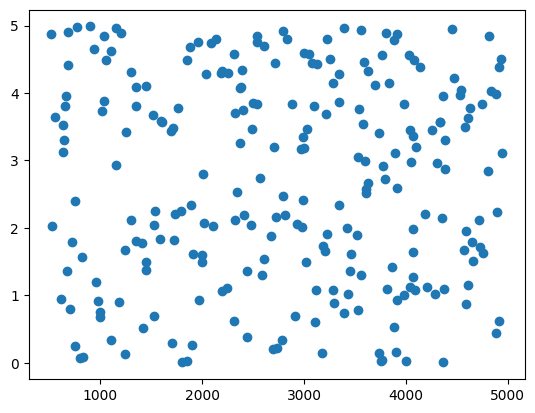

In [63]:
x = cp_row.Estimated_Reservoir_Depth
y = cp_row.Proximity_to_Oil_Field

plt.scatter(x, y)
plt.show()

In [7]:
cp_row.describe()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,15.426316,499.284687,0.485876,2.682992,2808.475207,0.264463
std,8.919082,291.527837,0.284503,1.510118,1270.591597,0.441961
min,0.048036,18.134529,0.006394,0.003744,517.000000,0.000000
25%,7.207491,256.740694,0.249579,1.382075,1741.500000,0.000000
50%,16.649783,462.358664,0.446967,2.770711,2922.000000,0.000000
75%,23.301967,751.218879,0.713240,4.021814,3885.500000,1.000000
max,29.949563,997.134762,0.997357,4.987292,4945.000000,1.000000


In [8]:
oilData.isna()

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,False,False,False,True,False,False,False,False
1,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,True,False
4,False,False,False,True,True,False,True,False
...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,True,False,False
2996,False,True,True,False,False,True,False,False
2997,False,False,False,False,False,True,False,False
2998,False,False,False,False,False,False,True,False


In [38]:
from sklearn import impute
df = oilData.drop(columns=['Oil_Presence'])
y = oilData['Oil_Presence']
#import sklearn.impute as kNNImputer


In [39]:
print(f"Missing values in Permeability BEFORE: {df['Permeability'].isnull().sum()}")
print(f"Missing values in Porosity BEFORE: {df['Porosity'].isnull().sum()}")
print(f"Missing values in Seismic_Score BEFORE: {df['Seismic_Score'].isnull().sum()}")
print(f"Missing values in Proximity_to_Oil_Field BEFORE: {df['Proximity_to_Oil_Field'].isnull().sum()}")
print(f"Missing values in Estimated_Reservoir_Depth BEFORE: {df['Estimated_Reservoir_Depth'].isnull().sum()}")

Missing values in Permeability BEFORE: 1186
Missing values in Porosity BEFORE: 803
Missing values in Seismic_Score BEFORE: 1050
Missing values in Proximity_to_Oil_Field BEFORE: 943
Missing values in Estimated_Reservoir_Depth BEFORE: 1268


In [40]:
# 2. Separate numeric and categorical columns
numeric_cols = [
    "Porosity",
    "Permeability",
    "Seismic_Score",
    "Proximity_to_Oil_Field",
    "Estimated_Reservoir_Depth",
]
categorical_cols = ["Rock_Type", "Trap_Type"]


In [41]:
# Encode categorical text columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, dummy_na=True, dtype=float)

In [42]:
# Scale the numerical columns to a 0-1 range
scaler = MinMaxScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

In [43]:
# Initialize and run the KNN Imputer
imputer = impute.KNNImputer(n_neighbors=5, weights='distance')
imputed_array = imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(imputed_array, columns=df_encoded.columns)

In [44]:
# Inverse-transform to bring numbers back to their original scale
df_imputed[numeric_cols] = scaler.inverse_transform(df_imputed[numeric_cols])

In [45]:
# Reverse the Encoding back to text categories
for col in categorical_cols:
    dummy_cols = [c for c in df_imputed.columns if c.startswith(f"{col}_")]
    df[col] = df_imputed[dummy_cols].idxmax(axis=1).str.replace(f"{col}_", "")
    df[col] = df[col].replace("nan", np.nan)

In [46]:
# Assign the final filled Porosity column back to our original dataframe
df["Porosity"] = df_imputed["Porosity"]
df["Permeability"] = df_imputed["Permeability"]
df['Seismic_Score'] = df_imputed["Seismic_Score"]
df['Proximity_to_Oil_Field'] = df_imputed["Proximity_to_Oil_Field"]
df['Estimated_Reservoir_Depth'] = df_imputed["Estimated_Reservoir_Depth"]

In [47]:
print(f"Missing values in Permeability BEFORE: {df['Permeability'].isnull().sum()}")
print(f"Missing values in Porosity BEFORE: {df['Porosity'].isnull().sum()}")
print(f"Missing values in Seismic_Score BEFORE: {df['Seismic_Score'].isnull().sum()}")
print(f"Missing values in Proximity_to_Oil_Field BEFORE: {df['Proximity_to_Oil_Field'].isnull().sum()}")
print(f"Missing values in Estimated_Reservoir_Depth BEFORE: {df['Estimated_Reservoir_Depth'].isnull().sum()}")

Missing values in Permeability BEFORE: 0
Missing values in Porosity BEFORE: 0
Missing values in Seismic_Score BEFORE: 0
Missing values in Proximity_to_Oil_Field BEFORE: 0
Missing values in Estimated_Reservoir_Depth BEFORE: 0


In [75]:
df['Oil_Presence'] = y
df['Trap_Type'] = df['Trap_Type'].replace(np.nan, 'None')

In [76]:
df.head(10)

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Limestone,17.667992,834.277472,None,0.705933,2.431355,2228.000000,1
1,Limestone,27.665758,578.158034,None,0.545806,2.606158,1610.000000,0
2,Sandstone,28.855946,404.790685,None,0.167530,1.143136,2344.000000,0
3,Sandstone,0.410957,887.836673,Dome,0.026852,2.673532,2278.500000,0
4,Shale,16.490538,562.288802,None,0.473552,2.064440,2099.000000,0
5,Shale,16.654792,979.154784,Anticline,0.044457,4.927771,3556.000000,1
6,Limestone,8.342985,928.375471,Fault,0.854888,0.439339,2138.000000,0
7,Shale,13.111546,263.806644,Fault,0.375041,4.602919,3424.000000,0
8,Shale,18.167926,692.010775,Fault,0.411637,0.672804,867.000000,0
9,Sandstone,28.419000,728.106328,Anticline,0.194321,4.097616,927.215967,0


In [30]:
# Check for negative values in physical measurements
print(f"Negative Porosity values: {(df['Porosity'] < 0).sum()}")
print(f"Negative Permeability values: {(df['Permeability'] < 0).sum()}")

Negative Porosity values: 0
Negative Permeability values: 0


In [66]:
df.to_csv('output.csv', index=False)

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X = df.drop(columns=('Oil_Presence'))
y = df['Oil_Presence']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [74]:
X_train.shape
#X_test.shape

(2400, 7)